In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [73]:
def ThomasSolve(a, b, c, d):
    N = len(b)
    # Forward elimination
    for i in range(1, N):
        w = a[i - 1] / b[i - 1]
        b[i] = b[i] - w * c[i - 1]
        d[i] = d[i] - w * d[i - 1]
    # Back substitution
    x = np.zeros(N)
    x[-1] = d[-1] / b[-1]
    for i in range(N - 2, -1, -1):
        x[i] = (d[i] - c[i] * x[i + 1]) / b[i]
    return x

In [74]:
def Solve(T, r, T_left, T_right, Nx, Nt):
    T_copy = T.copy()
    n_interior = Nx - 2
    a_A = np.full(n_interior - 1, -r/2)
    b_A = np.full(n_interior, 1 + r)
    c_A = np.full(n_interior - 1, -r/2)

    a_B = np.full(n_interior - 1, r/2)
    b_B = np.full(n_interior, 1 - r)
    c_B = np.full(n_interior - 1, r/2)

    for n in range(Nt):
        T_in = T_copy[1:-1]
        # 1) Form the RHS = B * T_old_interior + boundary terms
        RHS = np.zeros(n_interior)

        # Multiply B*T_in
        for i in range(n_interior):
            RHS[i] = b_B[i] * T_in[i]
            if i > 0:
                RHS[i] += a_B[i - 1] * T_in[i - 1]
            if i < n_interior - 1:
                RHS[i] += c_B[i] * T_in[i + 1]
        # Boundary from time n => + (r/2)* T_left or T_right
        # Boundary from time n+1 => also + (r/2)* T_left, T_right on the RHS
        # Summed = r* T_left, r* T_right for the first/last interior row
        RHS[0] += r * T_left
        RHS[-1] += r * T_right

        # 2) Solve A * T_in^{new} = RHS
        sol = ThomasSolve(a_A.copy(), b_A.copy(), c_A.copy(), RHS.copy())
        
        # 3) Put interior solution back + Dirichlet boundary
        T_copy[1: -1] = sol
        T_copy[0] = T_left
        T_copy[-1] = T_right

    return T_copy

# WS Example

In [78]:
# Parameters
L      = 1.0
Nx     = 51
Nt     = 5000

dx     = L/(Nx-1)
dt     = 0.1

alpha  = 1e-4

r      = alpha*dt/dx**2

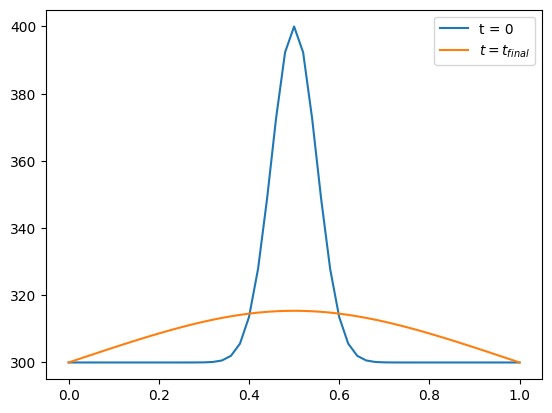

In [80]:
# discretizing the rod
x = np.linspace(0, L, Nx)
T0 = 300.0

T = np.full(Nx, 300.0)
sigma = 0.05
peak_amplitude = 100.0  # so peak is 300 + 100 = 400
for i in range(Nx):
    T[i] += peak_amplitude * np.exp(-(x[i] - 0.5*L)**2 / (2*sigma**2))

T[0] = T0
T[-1] = T0

# solving for T
T_Nt = Solve(T, r, T0, T0, Nx, Nt)

# ploting the initial and final solution
plt.plot(x, T, label='t = 0')
plt.plot(x, T_Nt, label=R'$t = t_{final}$')
plt.legend()
plt.show()